# Chapter 259 — Simulation Techniques
### Part VIII: Probability

Simulation is the empirical arm of probability. When a system is too complex for closed-form analysis, you simulate it — generate realizations of the random process, observe outcomes, and estimate quantities of interest. This chapter assembles the core toolkit: inverse transform sampling, rejection sampling, the Gillespie algorithm for continuous-time processes, and Euler-Maruyama for stochastic differential equations.

**Prerequisites:** Probability Distributions (ch248), Random Variables (ch247), Random Walks (ch258), Monte Carlo Methods (ch256), Numerical Integration (ch221).

## 1. Inverse Transform Sampling

If $F$ is a CDF and $U \sim \text{Uniform}(0,1)$, then $X = F^{-1}(U)$ has distribution $F$. This is exact and works for any distribution with an invertible CDF *(CDF introduced in ch248)*.

**Proof:** $P(X \leq x) = P(F^{-1}(U) \leq x) = P(U \leq F(x)) = F(x)$.

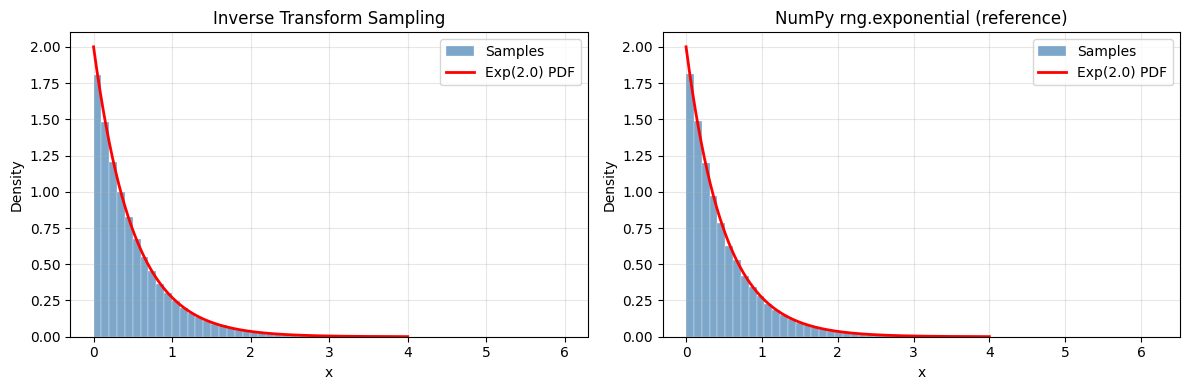

KS test: statistic=0.0030, p-value=0.3313 (p >> 0.05 = good)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)

# Sample from Exponential(lambda=2) via inverse transform
# CDF: F(x) = 1 - e^(-lambda x)   =>   F^{-1}(u) = -log(1-u)/lambda

def sample_exponential_via_it(lam, n, rng):
    """Sample Exponential(lambda) via inverse transform."""
    u = rng.uniform(0, 1, n)
    return -np.log(1 - u) / lam  # F^{-1}(u)

# Sample from a custom discrete distribution via inverse transform
def sample_discrete_via_it(values, probs, n, rng):
    """Sample from a discrete distribution using inverse CDF.
    
    Args:
        values: array of possible values
        probs: array of probabilities (must sum to 1)
        n: number of samples
        rng: numpy random generator
    
    Returns:
        samples from the specified discrete distribution
    """
    cdf = np.cumsum(probs)
    u = rng.uniform(0, 1, n)
    indices = np.searchsorted(cdf, u)
    return values[np.clip(indices, 0, len(values)-1)]

lam = 2.0
N = 100_000
samples_it = sample_exponential_via_it(lam, N, rng)
samples_scipy = rng.exponential(1/lam, N)  # scipy uses scale = 1/lambda

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x_range = np.linspace(0, 4, 300)
true_pdf = stats.expon.pdf(x_range, scale=1/lam)

for ax, samples, title in zip(axes, 
    [samples_it, samples_scipy],
    ['Inverse Transform Sampling', 'NumPy rng.exponential (reference)']):
    ax.hist(samples, bins=60, density=True, alpha=0.7, color='steelblue',
            edgecolor='white', linewidth=0.3, label='Samples')
    ax.plot(x_range, true_pdf, 'r-', linewidth=2, label=f'Exp({lam}) PDF')
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('inverse_transform.png', dpi=120, bbox_inches='tight')
plt.show()

ks_stat, ks_p = stats.kstest(samples_it, 'expon', args=(0, 1/lam))
print(f"KS test: statistic={ks_stat:.4f}, p-value={ks_p:.4f} (p >> 0.05 = good)")

## 2. Rejection Sampling

When $F^{-1}$ is unavailable, **rejection sampling** samples from a proposal $q(x) \geq p(x)/M$ (where $M$ is a constant, $\int p = \int q = 1$) and accepts with probability $p(x)/(M\,q(x))$.

Acceptance rate = $1/M$. Choose the tightest proposal possible.

Beta(2.5, 4.0) via rejection sampling:
  Acceptance rate: 0.250 (theoretical 1/M = 0.481)
  Sample mean: 0.3856 (true: 0.3846)


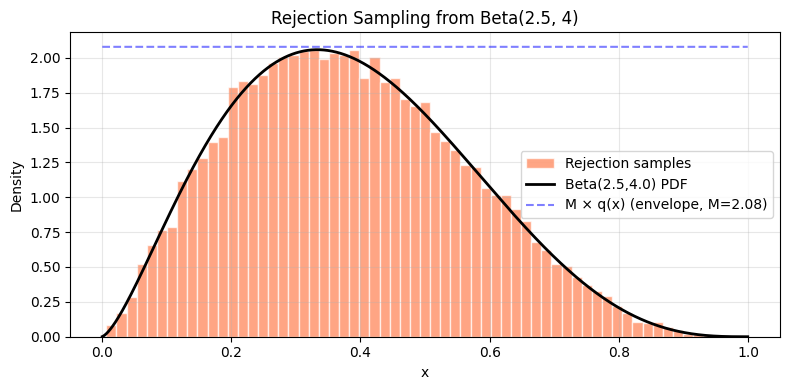

In [2]:
def rejection_sample(target_pdf, proposal_sampler, proposal_pdf, M, n_samples, rng):
    """Rejection sampling: sample from target_pdf using proposal.
    
    Args:
        target_pdf: callable, unnormalized target density p(x)
        proposal_sampler: callable(n) -> samples from proposal q
        proposal_pdf: callable, proposal density q(x)
        M: bounding constant such that p(x) <= M * q(x) for all x
        n_samples: desired number of accepted samples
        rng: numpy random generator
    
    Returns:
        accepted: array of accepted samples
        acceptance_rate: fraction of proposals accepted
    """
    accepted = []
    total_proposed = 0
    batch_size = max(n_samples * 2, 1000)  # over-sample in batches
    
    while len(accepted) < n_samples:
        x = proposal_sampler(batch_size)
        u = rng.uniform(0, 1, batch_size)
        accept_prob = target_pdf(x) / (M * proposal_pdf(x))
        mask = u < accept_prob
        accepted.extend(x[mask].tolist())
        total_proposed += batch_size
    
    accepted = np.array(accepted[:n_samples])
    return accepted, len(accepted) / total_proposed

# Target: Beta(2.5, 4) — no simple inverse CDF
# Proposal: Uniform(0,1)
alpha_b, beta_b = 2.5, 4.0

def beta_pdf(x):
    return stats.beta.pdf(x, alpha_b, beta_b)

# M = max of beta PDF (numerical)
x_grid = np.linspace(0.001, 0.999, 10000)
M = beta_pdf(x_grid).max() * 1.01  # slight buffer

samples_rs, accept_rate = rejection_sample(
    target_pdf=beta_pdf,
    proposal_sampler=lambda n: rng.uniform(0, 1, n),
    proposal_pdf=lambda x: np.ones_like(x),  # Uniform(0,1) density = 1
    M=M,
    n_samples=20_000,
    rng=rng
)

print(f"Beta({alpha_b}, {beta_b}) via rejection sampling:")
print(f"  Acceptance rate: {accept_rate:.3f} (theoretical 1/M = {1/M:.3f})")
print(f"  Sample mean: {samples_rs.mean():.4f} (true: {alpha_b/(alpha_b+beta_b):.4f})")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(samples_rs, bins=60, density=True, alpha=0.7, color='coral',
        edgecolor='white', label='Rejection samples')
ax.plot(x_grid, beta_pdf(x_grid), 'k-', linewidth=2, label=f'Beta({alpha_b},{beta_b}) PDF')
ax.plot(x_grid, M * np.ones_like(x_grid), 'b--', linewidth=1.5,
        alpha=0.5, label=f'M × q(x) (envelope, M={M:.2f})')
ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.set_title('Rejection Sampling from Beta(2.5, 4)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rejection_sampling.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Simulating Continuous-Time Processes: Gillespie Algorithm

Discrete event systems (chemical reactions, birth-death processes, queueing) evolve in continuous time with random event times. The **Gillespie algorithm** (exact stochastic simulation):

1. Compute total rate $\lambda_{\text{total}} = \sum_k \lambda_k$ (sum of all event rates)
2. Sample next event time: $\Delta t \sim \text{Exp}(\lambda_{\text{total}})$
3. Sample which event occurs: proportional to $\lambda_k$
4. Update state; repeat

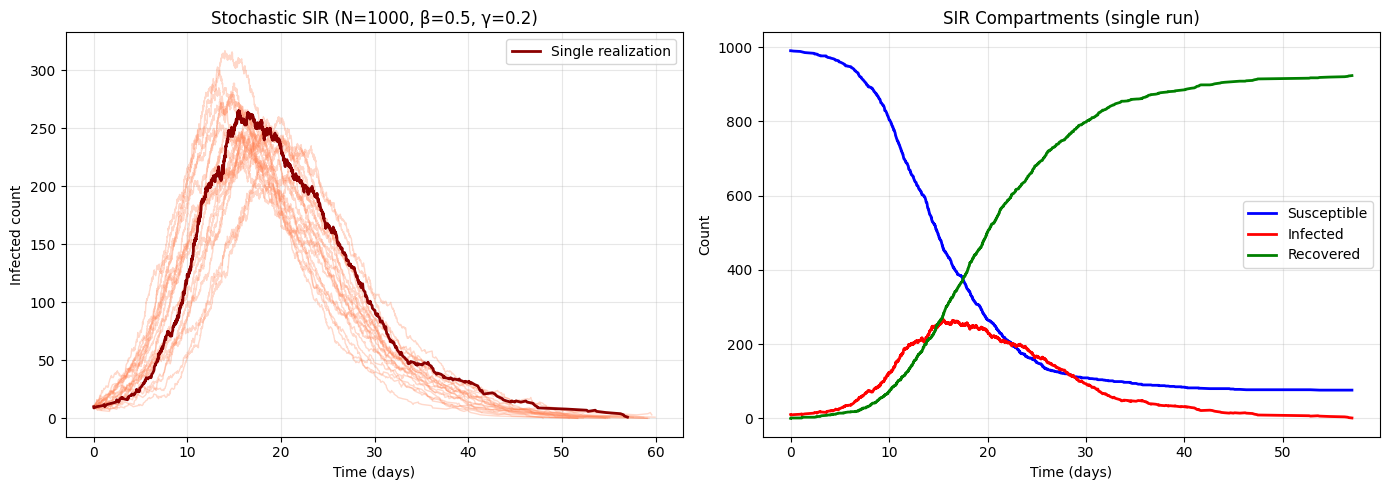

Peak infected across 20 simulations:
  Mean: 258.3
  Std:  25.1
  Min:  210
  Max:  317


In [3]:
def gillespie_sir(S0, I0, R0, beta, gamma, t_max, rng):
    """Exact stochastic SIR epidemic model via Gillespie algorithm.
    
    Events:
        Infection: S -> I at rate beta*S*I/N
        Recovery:  I -> R at rate gamma*I
    
    Args:
        S0, I0, R0: initial counts
        beta: infection rate
        gamma: recovery rate  
        t_max: maximum simulation time
        rng: numpy random generator
    
    Returns:
        times, S_traj, I_traj, R_traj: arrays of states at event times
    """
    N = S0 + I0 + R0
    S, I, R = S0, I0, R0
    t = 0.0
    
    times = [t]
    S_traj, I_traj, R_traj = [S], [I], [R]
    
    while t < t_max and I > 0:
        # Event rates
        rate_infect = beta * S * I / N
        rate_recover = gamma * I
        total_rate = rate_infect + rate_recover
        
        if total_rate == 0:
            break
        
        # Time to next event
        dt = rng.exponential(1.0 / total_rate)
        t += dt
        
        if t > t_max:
            break
        
        # Which event?
        if rng.random() < rate_infect / total_rate:
            S -= 1
            I += 1
        else:
            I -= 1
            R += 1
        
        times.append(t)
        S_traj.append(S)
        I_traj.append(I)
        R_traj.append(R)
    
    return np.array(times), np.array(S_traj), np.array(I_traj), np.array(R_traj)

# Parameters: R0 = beta/gamma = 2.5
S0, I0, R0 = 990, 10, 0
beta, gamma = 0.5, 0.2
t_max = 60

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Multiple stochastic realizations
n_sims = 20
peak_infecteds = []

for trial in range(n_sims):
    times, S_t, I_t, R_t = gillespie_sir(S0, I0, R0, beta, gamma, t_max, rng)
    axes[0].plot(times, I_t, alpha=0.3, linewidth=1, color='coral')
    peak_infecteds.append(I_t.max())

# One highlighted trajectory
times, S_t, I_t, R_t = gillespie_sir(S0, I0, R0, beta, gamma, t_max, rng)
axes[0].plot(times, I_t, 'darkred', linewidth=2, label='Single realization')
axes[0].set_xlabel('Time (days)')
axes[0].set_ylabel('Infected count')
axes[0].set_title(f'Stochastic SIR (N={S0+I0+R0}, β={beta}, γ={gamma})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Full compartment view
axes[1].plot(times, S_t, 'b-', linewidth=2, label='Susceptible')
axes[1].plot(times, I_t, 'r-', linewidth=2, label='Infected')
axes[1].plot(times, R_t, 'g-', linewidth=2, label='Recovered')
axes[1].set_xlabel('Time (days)')
axes[1].set_ylabel('Count')
axes[1].set_title('SIR Compartments (single run)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gillespie_sir.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Peak infected across {n_sims} simulations:")
print(f"  Mean: {np.mean(peak_infecteds):.1f}")
print(f"  Std:  {np.std(peak_infecteds):.1f}")
print(f"  Min:  {np.min(peak_infecteds)}")
print(f"  Max:  {np.max(peak_infecteds)}")

## 4. Euler-Maruyama: Simulating Stochastic Differential Equations

A stochastic differential equation (SDE) is:

$$dX_t = \mu(X_t, t)\,dt + \sigma(X_t, t)\,dW_t$$

where $dW_t = \sqrt{dt}\,Z$, $Z \sim N(0,1)$ (Brownian increment). The **Euler-Maruyama** discretization:

$$X_{t+\Delta t} = X_t + \mu(X_t, t)\Delta t + \sigma(X_t, t)\sqrt{\Delta t}\,Z_t$$

Application: Geometric Brownian Motion (GBM) models stock prices:
$dS_t = \mu S_t\,dt + \sigma S_t\,dW_t$ → $S_t = S_0 \exp\left((\mu - \sigma^2/2)t + \sigma W_t\right)$

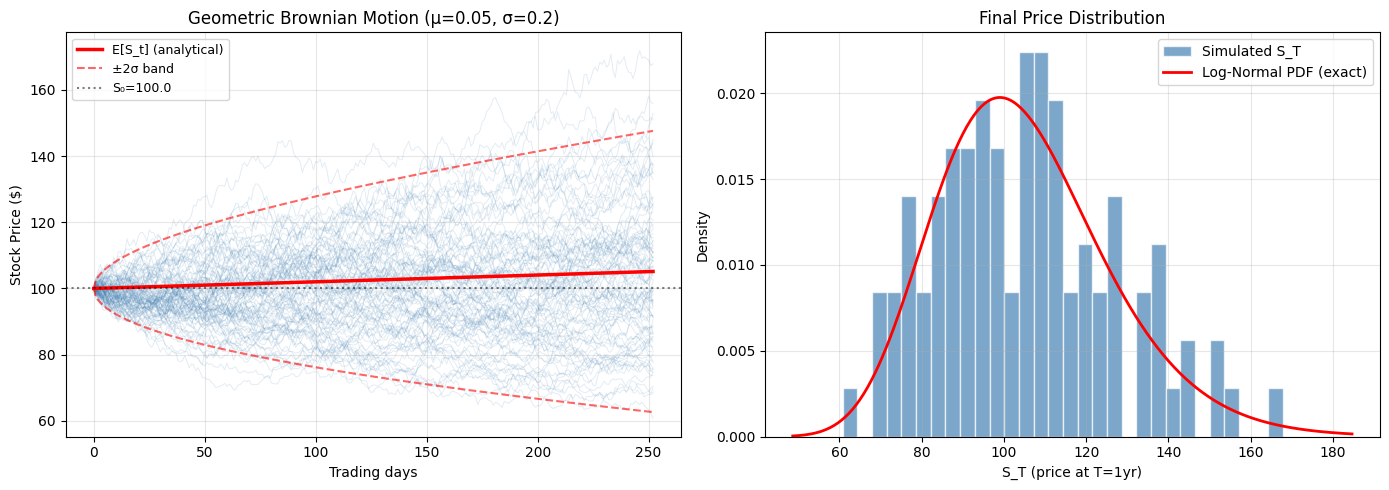

Final price statistics (N=100 paths):
  Simulated mean: $105.12  (theoretical: $105.13)
  Simulated std:  $21.79  (theoretical: $21.24)


In [4]:
def euler_maruyama(mu_fn, sigma_fn, x0, T, n_steps, n_paths, rng):
    """Euler-Maruyama simulation of an SDE.
    
    Args:
        mu_fn: drift function (x, t) -> scalar
        sigma_fn: diffusion function (x, t) -> scalar
        x0: initial value
        T: final time
        n_steps: number of time steps
        n_paths: number of independent paths
        rng: numpy random generator
    
    Returns:
        t_grid: time grid (n_steps+1,)
        paths: (n_steps+1, n_paths) array of simulated paths
    """
    dt = T / n_steps
    t_grid = np.linspace(0, T, n_steps + 1)
    paths = np.zeros((n_steps + 1, n_paths))
    paths[0] = x0
    
    sqrt_dt = np.sqrt(dt)
    
    for i in range(n_steps):
        t = t_grid[i]
        x = paths[i]
        Z = rng.standard_normal(n_paths)
        drift = np.vectorize(mu_fn)(x, t)
        diffusion = np.vectorize(sigma_fn)(x, t)
        paths[i+1] = x + drift * dt + diffusion * sqrt_dt * Z
    
    return t_grid, paths

# Geometric Brownian Motion: dS = mu*S dt + sigma*S dW
S0 = 100.0
mu_gbm = 0.05      # 5% annual drift
sigma_gbm = 0.20   # 20% annual volatility
T = 1.0            # 1 year
n_steps = 252      # daily steps
n_paths = 100

t_grid, paths = euler_maruyama(
    mu_fn=lambda x, t: mu_gbm * x,
    sigma_fn=lambda x, t: sigma_gbm * x,
    x0=S0, T=T, n_steps=n_steps, n_paths=n_paths,
    rng=rng
)

# Analytical solution
t_fine = np.linspace(0, T, 300)
analytical_mean = S0 * np.exp(mu_gbm * t_fine)
analytical_std = S0 * np.exp(mu_gbm * t_fine) * np.sqrt(np.exp(sigma_gbm**2 * t_fine) - 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in range(n_paths):
    axes[0].plot(t_grid * 252, paths[:, i], alpha=0.15, linewidth=0.7, color='steelblue')
axes[0].plot(t_fine * 252, analytical_mean, 'r-', linewidth=2.5, label='E[S_t] (analytical)')
axes[0].plot(t_fine * 252, analytical_mean + 2*analytical_std, 'r--', linewidth=1.5,
             alpha=0.6, label='±2σ band')
axes[0].plot(t_fine * 252, analytical_mean - 2*analytical_std, 'r--', linewidth=1.5, alpha=0.6)
axes[0].axhline(S0, color='black', linestyle=':', alpha=0.5, label=f'S₀={S0}')
axes[0].set_xlabel('Trading days')
axes[0].set_ylabel('Stock Price ($)')
axes[0].set_title(f'Geometric Brownian Motion (μ={mu_gbm}, σ={sigma_gbm})')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Final distribution
final_prices = paths[-1]
axes[1].hist(final_prices, bins=30, density=True, color='steelblue',
             alpha=0.7, edgecolor='white', label='Simulated S_T')

# Log-normal analytical distribution
log_mean = np.log(S0) + (mu_gbm - 0.5*sigma_gbm**2) * T
log_std = sigma_gbm * np.sqrt(T)
x_range = np.linspace(final_prices.min()*0.8, final_prices.max()*1.1, 300)
axes[1].plot(x_range, stats.lognorm.pdf(x_range, s=log_std, scale=np.exp(log_mean)),
             'r-', linewidth=2, label='Log-Normal PDF (exact)')
axes[1].set_xlabel('S_T (price at T=1yr)')
axes[1].set_ylabel('Density')
axes[1].set_title('Final Price Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gbm_simulation.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Final price statistics (N={n_paths} paths):")
print(f"  Simulated mean: ${final_prices.mean():.2f}  (theoretical: ${S0*np.exp(mu_gbm*T):.2f})")
print(f"  Simulated std:  ${final_prices.std():.2f}  (theoretical: ${analytical_std[-1]:.2f})")

## 5. Summary

| Technique | When to use | Complexity |
|-----------|------------|------------|
| Inverse Transform | CDF invertible analytically | O(n) |
| Rejection Sampling | Target density known up to constant | O(n/acceptance_rate) |
| Gillespie | Exact continuous-time discrete events | O(n_events) |
| Euler-Maruyama | SDEs, approximate continuous paths | O(n_paths × n_steps) |

## 9. Forward References

- **ch260 — Project: Monte Carlo π**: Applies basic simulation (geometric sampling) in a complete project.
- **ch283 — Bayesian Statistics** *(Part IX)*: Markov Chain Monte Carlo (MCMC) combines ch257 and this chapter — a Markov chain whose stationary distribution is the posterior, sampled via Metropolis-Hastings (a form of rejection sampling with memory).
- **ch298 — Build a Mini ML Library** *(Part IX)*: Stochastic gradient descent uses random sampling (mini-batches) as a computational simulation technique — the same randomness-for-tractability philosophy.